# Oppgave 2A – Romlig analyse av skoleberedskap

## Problemstilling
Hvordan varierer beredskapen for evakuering av skoleelever mellom norske sivilforsvarsdistrikter, målt som avstand til nærmeste offentlige tilfluktsrom og andel skoler innen 5 km dekning?

## Datasett
Analysen bruker følgende datasett:
- offentlige tilfluktsrom
- grunnskoler
- videregående skoler
- sivilforsvarsdistrikter
- beredskapsetater hentet med OSM overpass

Målet er å kombinere avstandsberegning, bufferanalyse, overlay og romlig aggregering for å si noe om geografisk variasjon i beredskap.

## Biblioteker

Her importeres bibliotekene som brukes til filinnlesing, romlige analyser, tabellbehandling og visualisering.

In [53]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from pathlib import Path

## Filstier

Her defineres stier til inputdata og outputmappe. Output lagres i prosjektets egen `outputs`-mappe.

In [54]:
DATA = Path("data")
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

## Innlesing av data

Her leses de fire sentrale datasettene inn som GeoDataFrames. Dette danner grunnlaget for resten av analysen.

In [55]:
shelters = gpd.read_file(DATA / "Offentlige_Tilfluktsrom.geojson")
grunnskoler = gpd.read_file(DATA / "Grunnskoler.geojson")
vgs = gpd.read_file(DATA / "Videregaendeskoler.geojson")
districts = gpd.read_file(DATA / "Sivilforsvarsdistrikter_ny.geojson")

## Første inspeksjon av data

Før analysen starter er det viktig å sjekke antall objekter, koordinatsystem og sentrale kolonner.

In [56]:
print("Tilfluktsrom:", len(shelters))
print("Grunnskoler:", len(grunnskoler))
print("Videregående skoler:", len(vgs))
print("Sivilforsvarsdistrikter:", len(districts))

print("\nCRS:")
print("shelters:", shelters.crs)
print("grunnskoler:", grunnskoler.crs)
print("vgs:", vgs.crs)
print("districts:", districts.crs)

print("\nKolonner i shelters:")
print(shelters.columns.tolist())

print("\nKolonner i districts:")
print(districts.columns.tolist())

Tilfluktsrom: 556
Grunnskoler: 2870
Videregående skoler: 583
Sivilforsvarsdistrikter: 20

CRS:
shelters: EPSG:4326
grunnskoler: EPSG:4326
vgs: EPSG:4326
districts: EPSG:4326

Kolonner i shelters:
['lokalId', 'navnerom', 'versjonId', 'datauttaksdato', 'opphav', 'romnr', 'plasser', 'adresse', 'objtype', 'geometry']

Kolonner i districts:
['OBJECTID', 'objtype', 'navn', 'lokalid', 'navnerom', 'versjonid', 'datauttaksdato', 'opphav', 'forstedigitaliseringsdato', 'oppdateringsdato', 'noyaktighet', 'malemetode', 'SHAPE_Length', 'SHAPE_Area', 'geometry']


## Reprojeksjon til meterbasert koordinatsystem

For avstand, buffer og arealbaserte operasjoner trenger vi et koordinatsystem i meter. Her reprojiseres alle lag til ETRS89 / UTM 33N (EPSG:25833).

In [57]:
target_crs = 25833

shelters = shelters.to_crs(target_crs)
grunnskoler = grunnskoler.to_crs(target_crs)
vgs = vgs.to_crs(target_crs)
districts = districts.to_crs(target_crs)

## Innledende visualisering

Dette kartet gir en første oversikt over hvordan tilfluktsrom, skoler og sivilforsvarsdistrikter er geografisk fordelt.

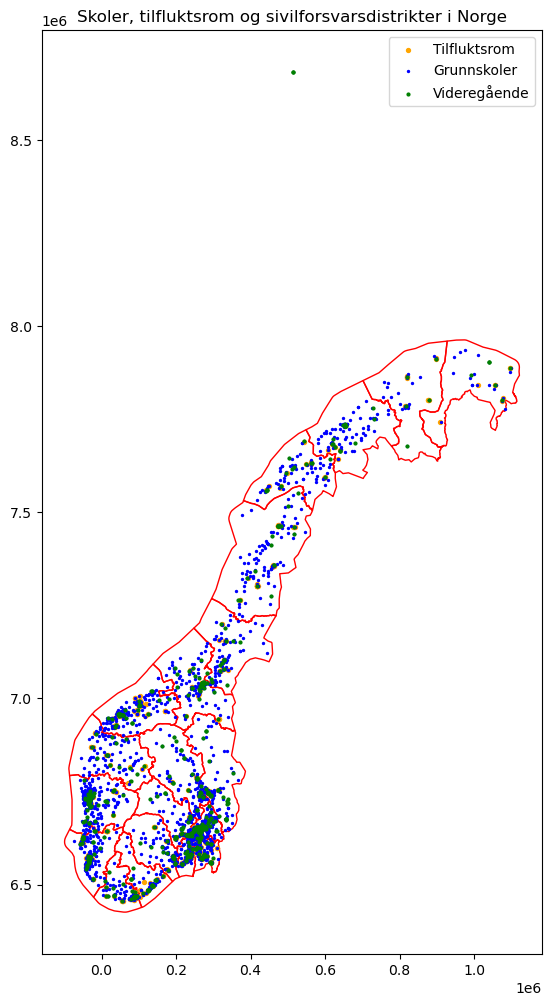

In [58]:
fig, ax = plt.subplots(figsize=(10, 12))

districts.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)
shelters.plot(ax=ax, color="orange", markersize=8, label="Tilfluktsrom")
grunnskoler.plot(ax=ax, color="blue", markersize=2, label="Grunnskoler")
vgs.plot(ax=ax, color="green", markersize=4, label="Videregående")

ax.set_title("Skoler, tilfluktsrom og sivilforsvarsdistrikter i Norge")
ax.legend()
plt.show()

## Avstand til nærmeste tilfluktsrom

Her beregnes avstanden fra hver skole til nærmeste offentlige tilfluktsrom. Dette gir et grunnleggende mål på geografisk tilgjengelighet.

In [59]:
grunnskoler["nearest_dist_m"] = grunnskoler.geometry.apply(lambda g: shelters.distance(g).min())
vgs["nearest_dist_m"] = vgs.geometry.apply(lambda g: shelters.distance(g).min())

print(grunnskoler["nearest_dist_m"].describe())
print(vgs["nearest_dist_m"].describe())

count      2870.000000
mean      11546.451510
std       22642.376185
min           0.504596
25%        1093.180573
50%        3767.876996
75%       14881.385402
max      859077.624062
Name: nearest_dist_m, dtype: float64
count       583.000000
mean      11330.944665
std       52269.545472
min           3.613947
25%         459.820730
50%        1263.564190
75%        6548.750388
max      859077.624062
Name: nearest_dist_m, dtype: float64


## Fordeling av avstander

Histogrammet viser hvordan avstanden til nærmeste tilfluktsrom varierer mellom grunnskoler og videregående skoler.

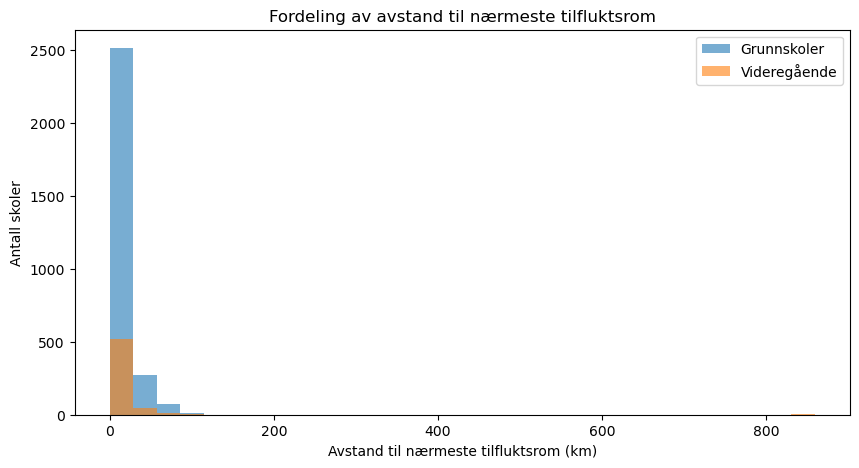

In [60]:
plt.figure(figsize=(10, 5))
plt.hist(grunnskoler["nearest_dist_m"] / 1000, bins=30, alpha=0.6, label="Grunnskoler")
plt.hist(vgs["nearest_dist_m"] / 1000, bins=30, alpha=0.6, label="Videregående")
plt.xlabel("Avstand til nærmeste tilfluktsrom (km)")
plt.ylabel("Antall skoler")
plt.title("Fordeling av avstand til nærmeste tilfluktsrom")
plt.legend()
plt.show()

## Bufferanalyse rundt tilfluktsrom

Her lages en buffersone på 5 km rundt alle tilfluktsrom. Denne brukes som en enkel modell for geografisk dekning.

In [61]:
buffer_gdf = shelters.copy()
buffer_gdf["geometry"] = shelters.buffer(5000)

buffer_union = buffer_gdf.union_all()
buffer_union_gdf = gpd.GeoDataFrame(geometry=[buffer_union], crs=shelters.crs)

## Skoler med og uten dekning

Ved hjelp av den sammenslåtte buffersonen deles skolene inn i skoler med dekning og skoler uten dekning innen 5 km.

In [62]:
grunnskoler_med = grunnskoler[grunnskoler.geometry.within(buffer_union)].copy()
grunnskoler_uten = grunnskoler[~grunnskoler.geometry.within(buffer_union)].copy()

vgs_med = vgs[vgs.geometry.within(buffer_union)].copy()
vgs_uten = vgs[~vgs.geometry.within(buffer_union)].copy()

print("Grunnskoler med dekning:", len(grunnskoler_med))
print("Grunnskoler uten dekning:", len(grunnskoler_uten))
print("Videregående med dekning:", len(vgs_med))
print("Videregående uten dekning:", len(vgs_uten))

Grunnskoler med dekning: 1574
Grunnskoler uten dekning: 1296
Videregående med dekning: 428
Videregående uten dekning: 155


## Statisk kart over dekning

Kartet viser buffersonen rundt tilfluktsrom og markerer hvilke skoler som faller utenfor dekning.

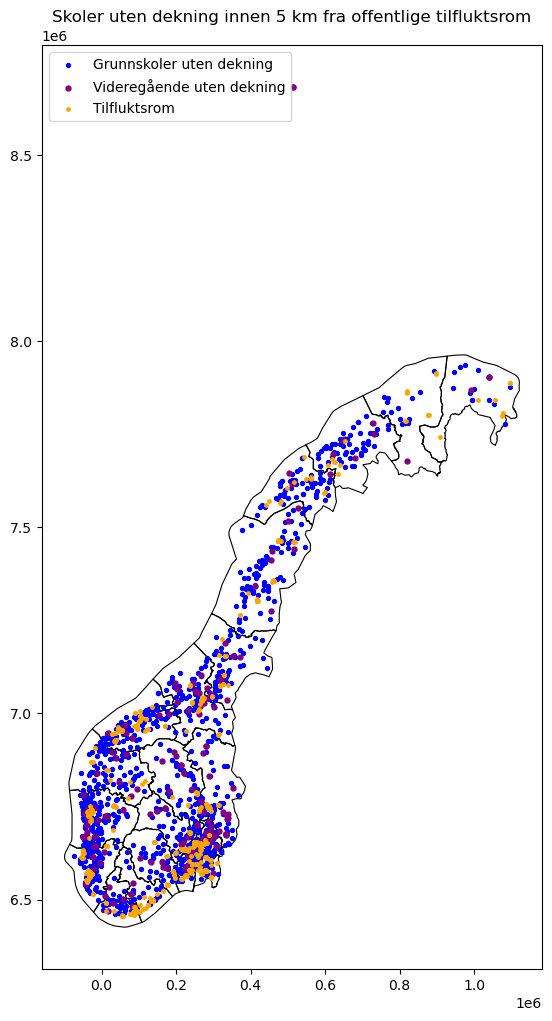

In [63]:
fig, ax = plt.subplots(figsize=(10, 12))

districts.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)
buffer_union_gdf.plot(ax=ax, color="lightgreen", alpha=0.4)
grunnskoler_uten.plot(ax=ax, color="blue", markersize=8, label="Grunnskoler uten dekning")
vgs_uten.plot(ax=ax, color="purple", markersize=12, label="Videregående uten dekning")
shelters.plot(ax=ax, color="orange", markersize=6, label="Tilfluktsrom")

ax.set_title("Skoler uten dekning innen 5 km fra offentlige tilfluktsrom")
ax.legend()
plt.show()

## Overlayanalyse

For å demonstrere overlay brukes en intersection-operasjon mellom skolebuffere og tilfluktsrom. Her er det viktig å telle unike tilfluktsrom, ikke bare antall treff.

In [64]:
school_buffers = grunnskoler.copy()
school_buffers["geometry"] = school_buffers.buffer(5000)

shelters_near_school_buffers = gpd.overlay(shelters, school_buffers[["lokalid", "geometry"]], how="intersection")

unique_shelters_near_schools = shelters_near_school_buffers["lokalId"].nunique()

print("Antall overlay-treff:", len(shelters_near_school_buffers))
print("Antall unike tilfluktsrom innen 5 km fra minst én grunnskole:", unique_shelters_near_schools)

Antall overlay-treff: 9531
Antall unike tilfluktsrom innen 5 km fra minst én grunnskole: 552


## Romlig aggregering per sivilforsvarsdistrikt

Her kobles skolene til sivilforsvarsdistrikter med spatial join. Deretter beregnes antall skoler totalt, antall skoler med dekning og dekningsgrad i prosent for hvert distrikt.

In [65]:
grunnskoler["school_type"] = "Grunnskole"
vgs["school_type"] = "Videregående"

schools = pd.concat([
    grunnskoler[["lokalid", "skolenavn", "antallelever", "nearest_dist_m", "school_type", "geometry"]],
    vgs[["lokalid", "skolenavn", "antallelever", "nearest_dist_m", "school_type", "geometry"]]
], ignore_index=True)

schools = gpd.GeoDataFrame(schools, geometry="geometry", crs=grunnskoler.crs)

schools["covered_5km"] = schools.geometry.within(buffer_union)

schools_in_district = gpd.sjoin(
    schools,
    districts[["navn", "geometry"]],
    how="left",
    predicate="within"
)

district_summary = (
    schools_in_district
    .dropna(subset=["navn"])
    .groupby("navn")
    .agg(
        schools_total=("lokalid", "count"),
        schools_covered=("covered_5km", "sum"),
        mean_distance_m=("nearest_dist_m", "mean"),
        median_distance_m=("nearest_dist_m", "median")
    )
    .reset_index()
)

district_summary["schools_not_covered"] = district_summary["schools_total"] - district_summary["schools_covered"]
district_summary["coverage_percent"] = (
    district_summary["schools_covered"] / district_summary["schools_total"] * 100
).round(1)

district_summary["mean_distance_km"] = (district_summary["mean_distance_m"] / 1000).round(2)
district_summary["median_distance_km"] = (district_summary["median_distance_m"] / 1000).round(2)

district_summary = district_summary.sort_values("coverage_percent", ascending=True)

district_summary[[
    "navn",
    "schools_total",
    "schools_covered",
    "schools_not_covered",
    "coverage_percent",
    "mean_distance_km",
    "median_distance_km"
]]

,navn,schools_total,schools_covered,schools_not_covered,coverage_percent,mean_distance_km,median_distance_km
11,Sogn og Fjordane SFD,111,26,85,23.4,20.73,20.10
8,Oppland SFD,141,41,100,29.1,24.65,14.34
2,Hedmark SFD,147,52,95,35.4,24.56,13.14
7,Nordland SFD,148,57,91,38.5,21.34,16.48
14,Troms SFD,119,50,69,42.0,21.86,6.62
6,Nord-Trøndelag SFD,113,48,65,42.5,14.07,8.57
4,Midtre Hålogaland SFD,99,43,56,43.4,11.93,7.42
18,Øst-Finnmark SFD,32,14,18,43.8,24.11,13.53
5,Møre og Romsdal SFD,211,109,102,51.7,9.29,4.20
12,Sør-Trøndelag SFD,213,111,102,52.1,11.79,3.70


## Lagring av aggregert tabell

Resultattabellen lagres som CSV. Dette viser også bruk av Pandas til tabellarbeid og eksport.

In [66]:
district_summary.to_csv(OUT / "district_coverage_summary.csv", index=False)
print("Lagret:", OUT / "district_coverage_summary.csv")

Lagret: outputs\district_coverage_summary.csv


## Visualisering av dekningsgrad per distrikt

Dette stolpediagrammet gjør det lettere å sammenligne distriktene og identifisere områder med svakest dekning.

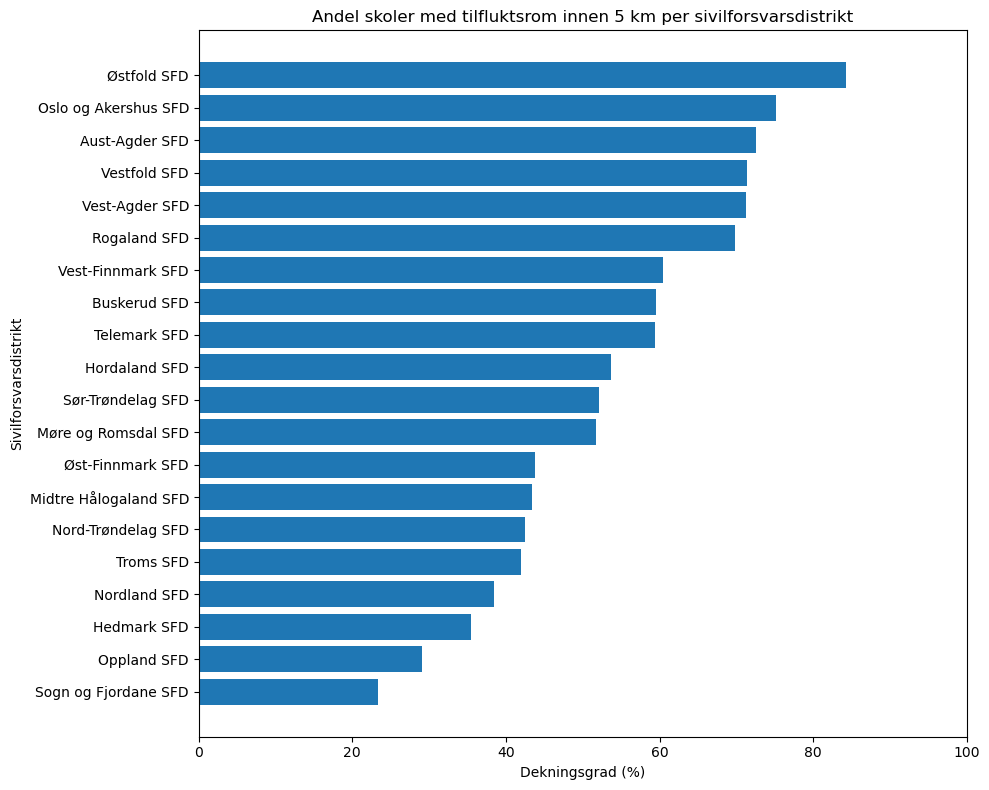

In [67]:
plot_df = district_summary.sort_values("coverage_percent", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["navn"], plot_df["coverage_percent"])
plt.xlabel("Dekningsgrad (%)")
plt.ylabel("Sivilforsvarsdistrikt")
plt.title("Andel skoler med tilfluktsrom innen 5 km per sivilforsvarsdistrikt")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Interaktiv visualisering med Folium

For å supplere de statiske kartene vises buffersonen og skolene uten dekning i et interaktivt kart.

In [68]:
shelters_wgs = shelters.to_crs(4326)
grunnskoler_uten_wgs = grunnskoler_uten.to_crs(4326)
vgs_uten_wgs = vgs_uten.to_crs(4326)
buffer_union_wgs = buffer_union_gdf.to_crs(4326)

m = folium.Map(location=[64.5, 12], zoom_start=5, tiles="CartoDB Voyager")

folium.GeoJson(
    buffer_union_wgs,
    name="5 km dekning",
    style_function=lambda x: {
        "fillColor": "green",
        "color": "green",
        "weight": 1,
        "fillOpacity": 0.2
    }
).add_to(m)

for _, row in grunnskoler_uten_wgs.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        popup=row.get("skolenavn", "Grunnskole"),
        fill=True
    ).add_to(m)

for _, row in vgs_uten_wgs.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        popup=row.get("skolenavn", "Videregående"),
        fill=True
    ).add_to(m)

folium.LayerControl().add_to(m)

m.save(OUT / "dekning_kart.html")
m

## Rasteranalyse

Oppgaven krever også en enkel dokumentasjon av rasteranalyse. Her vises eksempel på GDAL-kommandoer som kan brukes for å lage slope, polygonize og hillshade fra en DEM.

Disse kommandoene viser hvordan bratte områder kan identifiseres og konverteres til polygoner, og hvordan ulike hillshade-parametere gir ulike terrengframstillinger.

Eksempel på arbeidsflyt med GDAL:

```bash
gdalwarp dem.tif dem_utm33.tif -t_srs EPSG:25833

gdaldem slope dem_utm33.tif slope.tif

gdal_calc.py -A slope.tif --outfile=slope_over_30.tif --calc="A>30" --NoDataValue=0

gdal_polygonize.py slope_over_30.tif -f "GeoJSON" slope_over_30.geojson

gdaldem hillshade dem_utm33.tif hillshade_1.tif -az 315 -alt 45
gdaldem hillshade dem_utm33.tif hillshade_2.tif -az 225 -alt 30




---

## Tolkning av resultater

Resultatene viser at beredskapen ikke er jevnt fordelt mellom distriktene. Noen sivilforsvarsdistrikter har høy andel skoler innen 5 km fra offentlige tilfluktsrom, mens andre har svakere dekning og lengre gjennomsnittlig avstand.

Analysen er likevel begrenset fordi den bygger på luftlinjeavstand, ikke faktisk reisetid eller veinett. I tillegg dekker datasettet bare offentlige tilfluktsrom, ikke private.

## Konklusjon

Notebooken viser hvordan GeoPandas, Pandas og romlige metoder kan brukes til å analysere skoleberedskap i Norge. Kombinasjonen av nærmeste nabo, bufferanalyse, overlay og romlig aggregering gir et bedre grunnlag for å vurdere geografiske forskjeller i beredskap enn en ren kartvisualisering alene.